In [53]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from u_shaped_lib import CSH, OSA, beatnote_drift as bd, HighFinesse_FN as HF #Modified data is used, so we load CSH and not CSH_unmodified (where division with prop factor is needed)

In [54]:

root_dir = Path(r"C:\Users\au617810\OneDrive - Aarhus universitet\O-drive - Jeppe\U-shaped laser\New gen\Various polarizations measurements\Polarization vs feedback")

# ---- Helper: parse feedback power/step from folder name ----
# Capture: number + unit, e.g. "31.3µW", "0.1 nW", "1mW"
_feedback_pat = re.compile(
    r"(?i)\s*(?P<val>\d+(?:[.,]\d+)?)\s*(?P<unit>nw|uw|µw|μw|mw|w)\s*$"
)

_unit_to_mW = {
    "nw": 1e-6,   # 1 nW = 1e-6 mW
    "uw": 1e-3,   # 1 uW = 1e-3 mW
    "µw": 1e-3,
    "μw": 1e-3,
    "mw": 1.0,
    "w":  1e3,    # 1 W = 1000 mW
}

def parse_feedback_mW(folder_name: str) -> float:
    """
    Returns feedback power in mW parsed from folder names like:
    '31.3µW', '313µW', '0.1nW', '1mW', '2 W'
    Returns np.nan if it cannot parse.
    """
    s = folder_name.strip()
    m = _feedback_pat.match(s)
    if not m:
        return np.nan

    val = float(m.group("val").replace(",", "."))
    unit = m.group("unit").lower()
    return val * _unit_to_mW[unit]


def load_power_200_counts(power_txt_path, splitter_factor=20, to_mW=1e3):
    """
    Your existing logic:
      power = power_data[:,1] * 20 * 1e3  (mW)
    """
    p = pd.read_csv(power_txt_path, delimiter=" ", skiprows=1, names=["time", "power"])
    p["time"] = pd.to_datetime(p["time"], format="%Y-%m-%d_%H-%M-%S-%f", errors="coerce")
    power_mW = p["power"].to_numpy() * splitter_factor * to_mW
    return float(np.nanmean(power_mW)), float(np.nanstd(power_mW))

def pretty_parameter(name: str) -> str:
    s = name.replace("_", " ")
    s = s.replace(" deg", "°")
    s = s.replace("Deg", "°")
    s = s.replace("deg", "°")
    s = s.replace("  ", " ")
    return s


for x in ["31.3µW", "313µW", "0.1nW", "10nW", "100nW", "1µW", "1mW", "2W", "31.3 uW", "31,3µW"]:
    print(x, "->", parse_feedback_mW(x), "mW")


31.3µW -> 0.0313 mW
313µW -> 0.313 mW
0.1nW -> 1e-07 mW
10nW -> 9.999999999999999e-06 mW
100nW -> 9.999999999999999e-05 mW
1µW -> 0.001 mW
1mW -> 1.0 mW
2W -> 2000.0 mW
31.3 uW -> 0.0313 mW
31,3µW -> 0.0313 mW


In [55]:
root = Path(root_dir)
for param_dir in [d for d in root.iterdir() if d.is_dir()]:
    continue


for fb_dir in [d for d in param_dir.iterdir() if d.is_dir()]:    
    print(fb_dir.name)
    fb_folder = fb_dir.name
    fb_mW = parse_feedback_mW(fb_folder)
    print(fb_mW)
    

print(fb_dir)
data_check = CSH.get_data(str(fb_dir/"200 counts"))

print(np.average(data_check[0]),np.std(data_check[0],ddof=1))

100nW
9.999999999999999e-05
100µW
0.1
10nW
9.999999999999999e-06
10µW
0.01
17.8µW
0.0178
1nW
1e-06
1µW
0.001
31.3µW
0.0313
34µW
0.034
C:\Users\au617810\OneDrive - Aarhus universitet\O-drive - Jeppe\U-shaped laser\New gen\Various polarizations measurements\Polarization vs feedback\Slightly misaligned (45 deg on Poincaré)\34µW
Linewidths found from average between 900.0 kHz and 1000.0 kHz
9658264.263562413 2629280.7391269268


In [ ]:
#Fix power splitting ratio, or use actual power measured. 
#Calculate effective linewidth using beta line 


def build_linewidth_df(root_dir: str, power_splitter_factor: float = 1) -> pd.DataFrame:
    root = Path(root_dir)
    rows = []

    for param_dir in [d for d in root.iterdir() if d.is_dir()]:
        param_raw = param_dir.name
        param_pretty = pretty_parameter(param_raw)
        print(param_pretty)
        # feedback subfolders like "31.3µW", "0.1nW", "1mW"
        for fb_dir in [d for d in param_dir.iterdir() if d.is_dir()]:
            fb_folder = fb_dir.name
            fb_mW = parse_feedback_mW(fb_folder)

            # expected method subfolders
            csh_dir = fb_dir / "200 counts"
            hf_dir = fb_dir / "HF"
            if not hf_dir.exists():
                hf_dir = fb_dir / "HighFinesse"

            # ---- CSH (200 counts, typically 15-20 txt files) ----
            if csh_dir.exists():
                csh = CSH.get_data(str(csh_dir))
                lw = np.asarray(csh[0], dtype=float)  # first element is linewidth array (Hz)
                freq = np.asarray(csh[1], dtype=float)  # second element is frequency array (Hz)
                frequency_noise = np.asarray(csh[2], dtype=float)  # third element is frequency noise array (Hz^2/Hz)

                pm_data = pd.read_csv(csh_dir / "power.txt", delimiter=' ', skiprows=1, names=['time', 'power', 'feedback_power'])
                pm_data['time'] = pd.to_datetime(pm_data['time'], format='%Y-%m-%d_%H-%M-%S-%f')
                pm_data['delta_time'] = (pm_data['time'] - pm_data['time'].iloc[0]).dt.total_seconds()

                pm_time = pm_data['time'].values
                pm_delta_time = pm_data['delta_time'].values

                ###############
                pm_power = pm_data['power'].values * power_splitter_factor
                pm_fb_power = pm_data['feedback_power'].values * power_splitter_factor

                ##############


                for k, v in enumerate(lw):
                    rows.append({
                        "parameter_raw": param_raw,
                        "parameter": param_pretty,
                        "feedback_folder": fb_folder,
                        "feedback_mW": fb_mW,
                        "PM time": pm_time[k] if k < len(pm_data) else pd.NaT,
                        "PM delta_time_s": pm_delta_time[k] if k < len(pm_data) else np.nan,
                        "PM power_mW": pm_power[k] if k < len(pm_power) else np.nan,
                        "PM feedback_power_mW": pm_fb_power[k] if k < len(pm_fb_power) else np.nan,
                        "method": "CSH",
                        "trace_id": k,
                        "linewidth_Hz": float(v),
                        "frequency_Hz": freq[k],
                        "frequency_noise": frequency_noise[k],
                        "source_dir": str(csh_dir),
                    })

            # ---- HF (10 txt files) ----
            if hf_dir.exists():
                hf = HF.get_data(str(hf_dir))
                lw = np.asarray(hf[0], dtype=float)  # first element is linewidth array (Hz)
                freq = np.asarray(hf[1], dtype=float)  # second element is frequency array (Hz)
                frequency_noise = np.asarray(hf[2], dtype=float)  # third element is frequency noise array (Hz^2/Hz)
                for k, v in enumerate(lw):
                    rows.append({
                        "parameter_raw": param_raw,
                        "parameter": param_pretty,
                        "feedback_folder": fb_folder,
                        "feedback_mW": fb_mW,
                        "method": "HF",
                        "trace_id": k,
                        "linewidth_Hz": float(v),
                        "frequency_Hz": freq[k],
                        "frequency_noise": frequency_noise[k],
                        "source_dir": str(hf_dir),
                    })

    df_long = pd.DataFrame(rows)
    df_long["linewidth_kHz"] = df_long["linewidth_Hz"] * 1e-3
    return df_long

df_long = build_linewidth_df(root_dir)

Completely aligned
Linewidths found from average between 900.0 kHz and 1000.0 kHz
Linewidths found from average between 900.0 kHz and 1000.0 kHz
Linewidths found from average between 900.0 kHz and 1000.0 kHz
Linewidths found from average between 900.0 kHz and 1000.0 kHz
Linewidths found from average between 900.0 kHz and 1000.0 kHz
Linewidths found from average between 900.0 kHz and 1000.0 kHz
Linewidths found from average between 900.0 kHz and 1000.0 kHz
Linewidths found from average between 900.0 kHz and 1000.0 kHz
Linewidths found from average between 900.0 kHz and 1000.0 kHz
Linewidths found from average between 900.0 kHz and 1000.0 kHz
Linewidths found from average between 900.0 kHz and 1000.0 kHz
Linewidths found from average between 900.0 kHz and 1000.0 kHz
Linewidths found from average between 900.0 kHz and 1000.0 kHz
Linewidths found from average between 900.0 kHz and 1000.0 kHz
Linewidths found from average between 900.0 kHz and 1000.0 kHz
Linewidths found from average betwee

In [57]:
#STD uses DDOF=1, best for uncertainty in the mean

def summarize_linewidth(df_long: pd.DataFrame):
    df_sum = (
        df_long
        .groupby(["parameter", "parameter_raw", "feedback_folder", "feedback_mW", "method"], dropna=False)
        .agg(
            lw_Hz_mean=("linewidth_Hz", "mean"),
            lw_Hz_std=("linewidth_Hz", "std"),
            n=("linewidth_Hz", "count"),
        )
        .reset_index()
    )
    return df_sum

df_sum = summarize_linewidth(df_long)

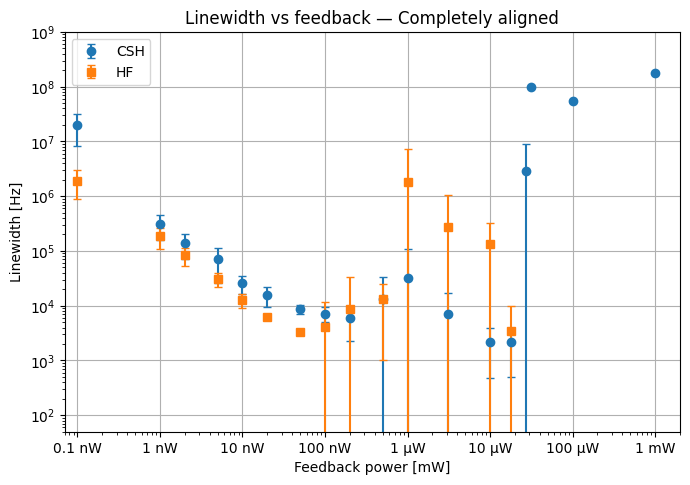

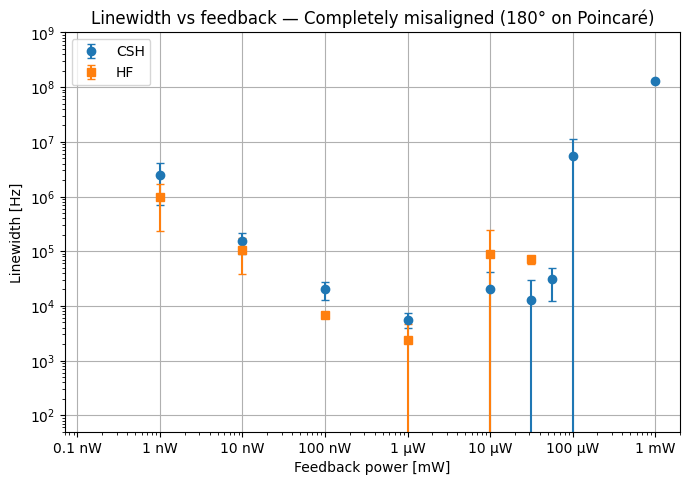

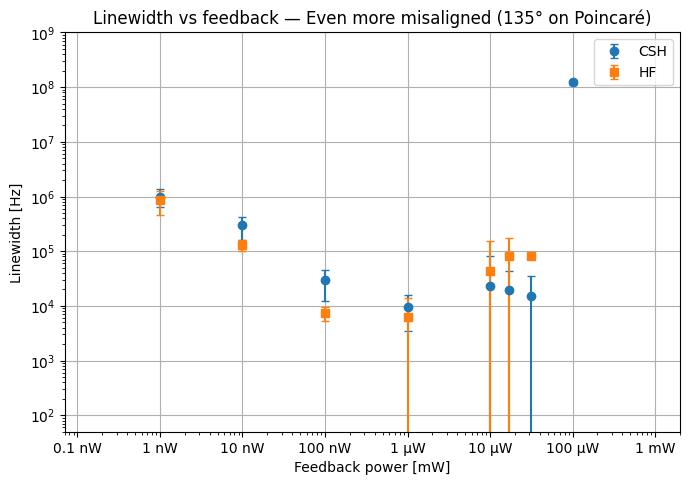

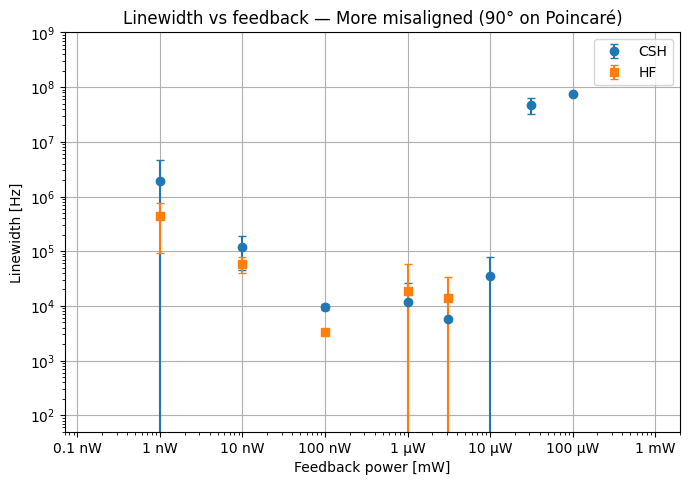

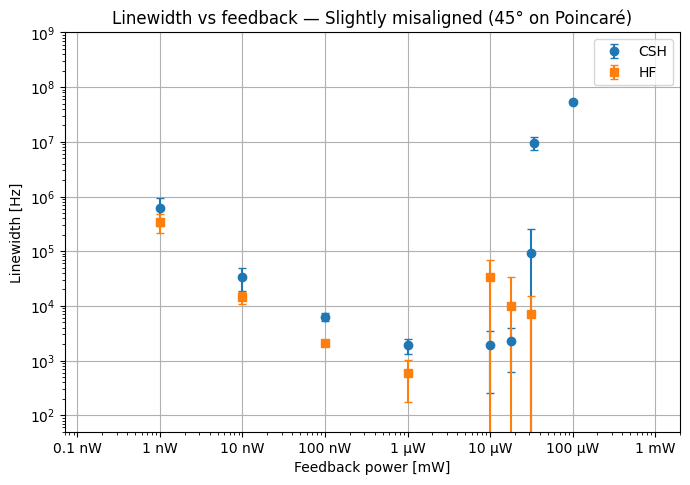

In [58]:
def plot_linewidth_vs_feedback(df_sum: pd.DataFrame, yscale="log", xscale="log"):
    for param in sorted(df_sum["parameter"].unique()):
        sub = df_sum[df_sum["parameter"] == param].copy()

        # If feedback_mW couldn't be parsed for some folders, you'll see NaN
        # You can either drop them or plot vs folder label instead
        sub = sub.dropna(subset=["feedback_mW"]).sort_values("feedback_mW")
        if sub.empty:
            print(f"No numeric feedback parsed for: {param}")
            continue

        plt.figure(figsize=(7, 5))

        for method, fmt in [("CSH", "o"), ("HF", "s")]:
            msub = sub[sub["method"] == method]
            if msub.empty:
                continue

            plt.errorbar(
                msub["feedback_mW"],
                msub["lw_Hz_mean"],
                yerr=msub["lw_Hz_std"],
                fmt=fmt,
                capsize=3,
                label=method,
            )

        if yscale:
            plt.yscale(yscale)
        if xscale:
            plt.xscale(xscale)

        plt.grid(True, which="major")
        plt.xlabel("Feedback power [mW]")
        plt.ylabel("Linewidth [Hz]")
        plt.title(f"Linewidth vs feedback — {param}")
        plt.legend()
        plt.tight_layout()
        plt.ylim([5e1,1e9])
        plt.xlim([7e-8, 2e0])
        plt.xticks(ticks=[1e-7, 1e-6, 1e-5, 1e-4,1e-3,1e-2,1e-1,1e-0], labels=['0.1 nW', '1 nW', '10 nW', '100 nW', '1 µW', '10 µW', '100 µW', '1 mW'])

        
        plt.show()

plot_linewidth_vs_feedback(df_sum, yscale="log")